The goal of this code is to create patches but allow points on the edge. This is an updated version of the previous CreatePatches.ipynb code. 

In [2]:
import numpy as np
from matplotlib import pyplot as plt 

Below is the code from the original createpatches file. 

In [3]:
import numpy as np
from skimage import data
import matplotlib.pyplot as plt 
import math

def randomPatches(resized_img, patch_size, num_patches):
    collect = []
    for i in range(num_patches):
        img_to_arr = np.asarray(resized_img)
        x = np.random.randint(img_to_arr.shape[0]-patch_size)
        y = np.random.randint(img_to_arr.shape[1]-patch_size)
        print(f"Upper Left Coordinate: ({x}, {y})")
        random_patches = img_to_arr[x:x+patch_size, y:y + patch_size]
        collect.append(random_patches)
    return collect

def patchGrid(resized_img, patch_size, overlap):
    step_size = patch_size - overlap
    height, width = resized_img.shape[:2]
    patches = []
    for y in range(0, height - patch_size + 1, step_size):
        for x in range(0, width - patch_size + 1, step_size):
            patch = resized_img[y:y+patch_size, x:x+patch_size]
            patches.append(patch)
    return patches

(872, 1000, 3)
Upper Left Coordinate: (44, 344)
Upper Left Coordinate: (664, 756)
Upper Left Coordinate: (723, 212)
Upper Left Coordinate: (9, 299)
Upper Left Coordinate: (394, 417)
Upper Left Coordinate: (280, 309)
Upper Left Coordinate: (621, 715)
Upper Left Coordinate: (317, 15)
Upper Left Coordinate: (356, 602)
Upper Left Coordinate: (144, 752)


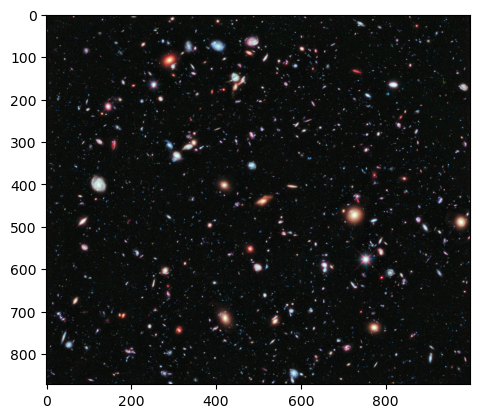

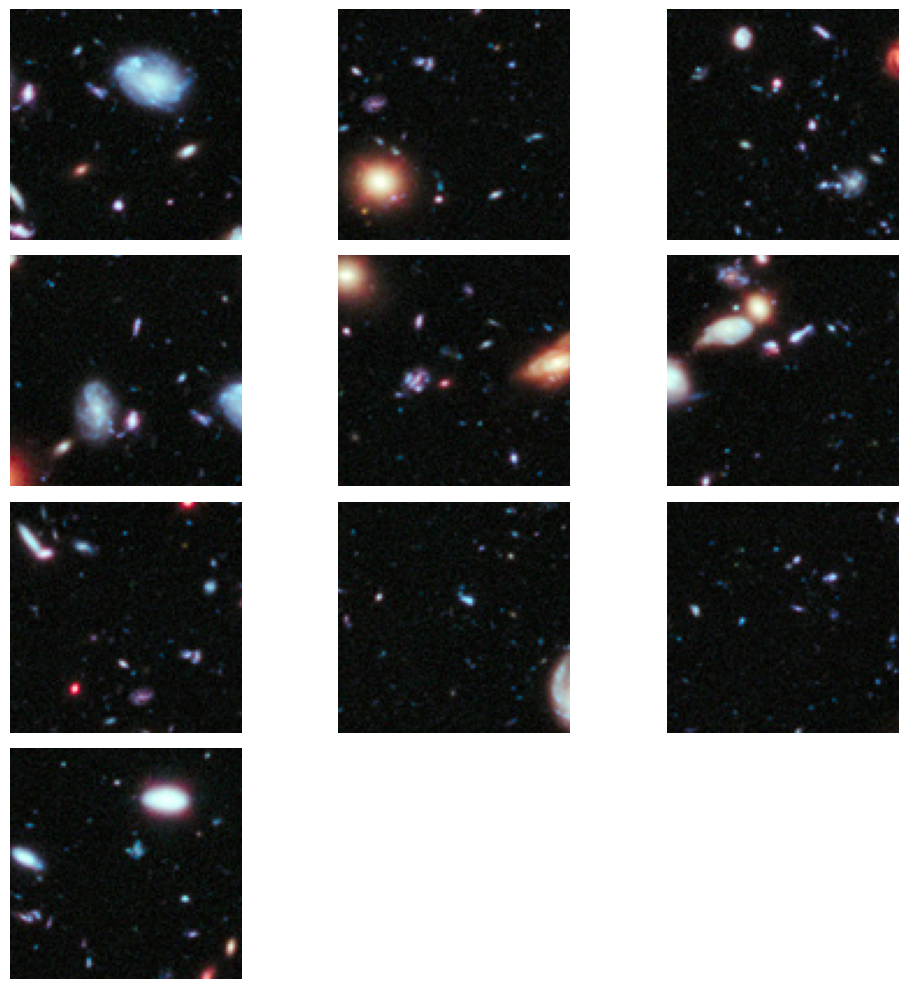

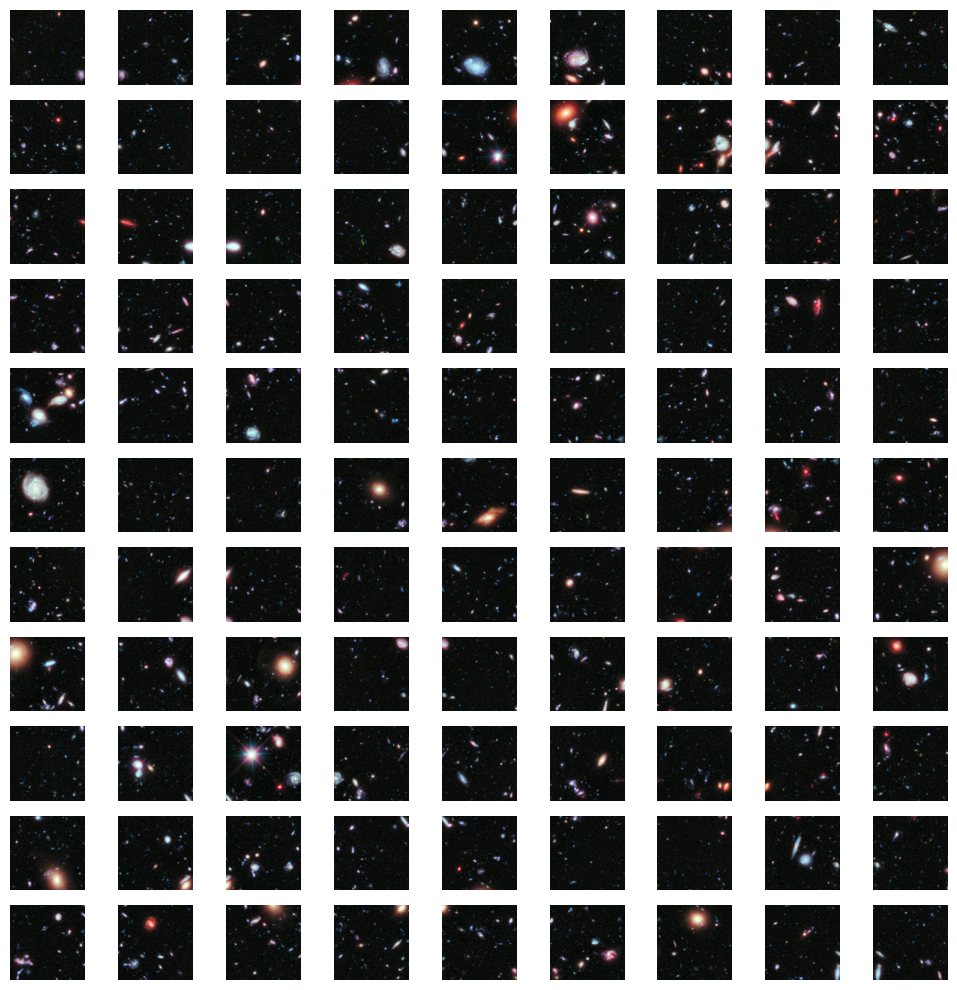

In [4]:
# Test on sklearn images
image = data.hubble_deep_field()
print(image.shape)
plt.imshow(image)

patches = randomPatches(image, 100, 10)

n = len(patches)
cols = int(math.sqrt(n))
rows = math.ceil(n/cols)
plt.figure(figsize = (10,10))
for i, patch in enumerate(patches):
    plt.subplot(rows, cols, i+1)
    plt.imshow(patch)
    plt.axis('off')
plt.tight_layout()
plt.show()

image = data.hubble_deep_field()

patches = patchGrid(image, 100, 10)

n = len(patches)
cols = int(math.sqrt(n))
rows = math.ceil(n/cols)
plt.figure(figsize = (10,10))
for i, patch in enumerate(patches):
    plt.subplot(rows, cols, i+1)
    plt.imshow(patch)
    plt.axis('off')
plt.tight_layout()
plt.show()


I want to create a function that allows one to select random vs grid and then allows people to mirror if they want to. 

In [22]:
def CreatePatches(image, patch_size, num_patches, overlap, method = 'random', mirror_edges = True):
    '''
    This function takes in a resized thin section image and returns a collection of image patches for thin section sorting. 
    Inputs: 
        - image: The thin section image to patch. 
        - patch_size: This should be a pixel size for patches. Patches are assumed to be square, so input will be the width/length of square patches. 
        - num_patches: Only relevant if method = 'random'. This will give the number of randomly generated patches to create from the image. 
        - overlap: This specifies the number of pixels to overlap between each patch on the grid or the allowed overlap in random patches.
        - method: Options are 'random' and 'grid'. 'random' will generate a random number of patches according to num_patches. 'grid' will generate patches on a grid. 
        - mirror_edges: Optional mirroring of the edges. This helps deal with edges of thin sections. In this case, edges are mirrored and patches are only allowed to be generated up to the original edge of the image.
        mirror_edges will only pad out to the last pixel that we could get using patch_size.
    Outputs:
        - patches: The collection of thin section patches according to user specifications.
        - coordinates: The coordinates of each generated patch on the image.
    '''
    patches = []
    img_array = np.asarray(image)
    if mirror_edges == True:
        img_array = np.pad(img_array, pad_width=((patch_size, patch_size), (patch_size, patch_size), (0, 0)), mode='reflect')
    if method == 'random':
        coordinates = np.zeros((num_patches, 2))
        if mirror_edges:
            y_max = img_array.shape[1] - patch_size
            y_min = patch_size
            x_max = img_array.shape[0] - patch_size
            x_min = patch_size
        if not mirror_edges:
            y_max = img_array.shape[1]
            y_min = 0
            x_max = img_array.shape[0]
            x_min = 0
        for i in range(num_patches):
            # Randomly generate coordinates
            x = np.random.randint(x_min, x_max)
            y = np.random.randint(y_min, y_max)

            # Save coordinates of random patch
            if mirror_edges:
                coordinates[i, 0] = x - patch_size
                coordinates[i, 1] = y - patch_size 
            if not mirror_edges:
                coordinates[i, 0] = x
                coordinates[i, 1] = y

            random_patch = img_array[x:x + patch_size, y:y + patch_size]
            patches.append(random_patch)
    if method == 'grid':
        step_size = patch_size - overlap
        if mirror_edges:
            height, width = img_array.shape[0] - patch_size, img_array.shape[1] - patch_size
            x_min = patch_size
            y_min = patch_size
        if not mirror_edges:
            height, width = img_array.shape[0], img_array.shape[1]
            x_min = 0
            y_min = 0 
        patches = []
        coordinates = []
        for x in range(patch_size, height - patch_size + 1, step_size):
            for y in range(patch_size, width - patch_size + 1, step_size):
                grid_patch = img_array[x:x + patch_size, y:y + patch_size]
                patches.append(grid_patch)
                coordinates.append((x,y))
        coordinates = np.asarray(coordinates)
    if method != 'grid' and method != 'random':
        print("Please select a valid method")
        return None, None
    return patches, coordinates

(872, 1000, 3)


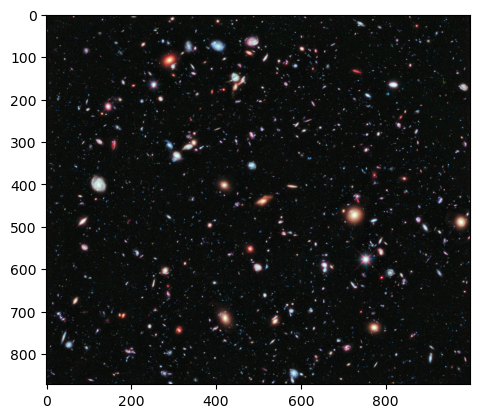

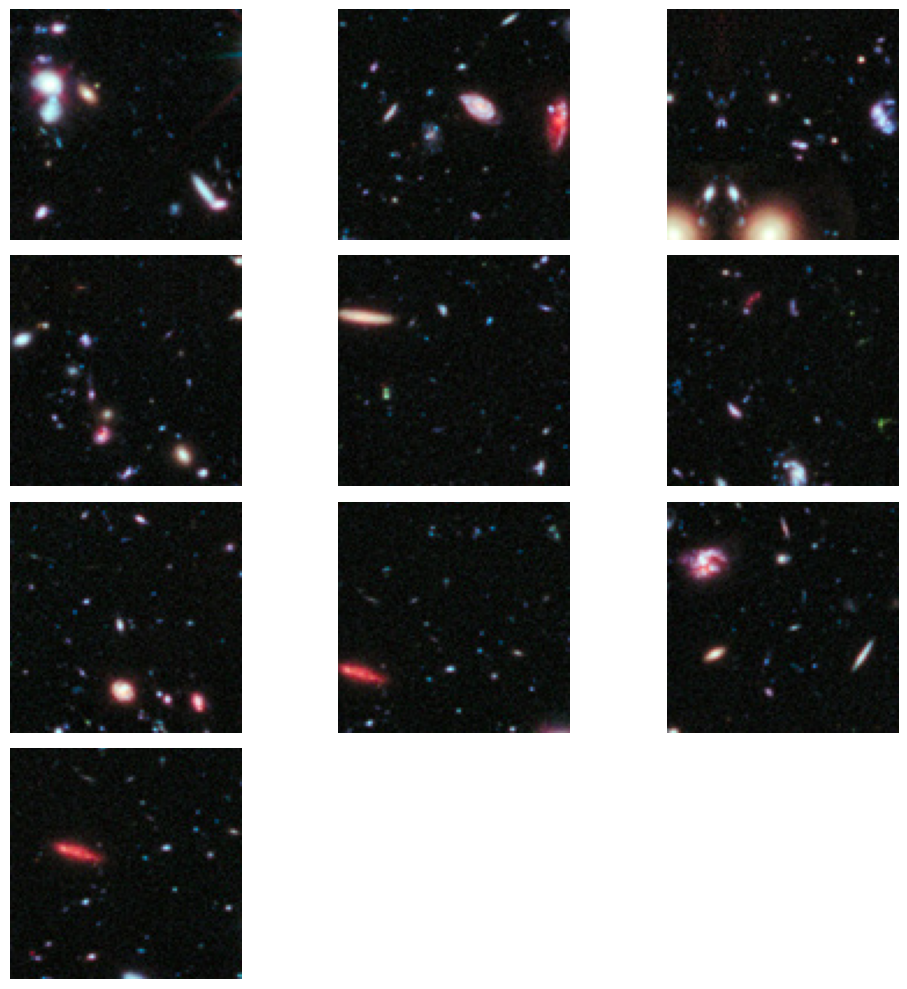

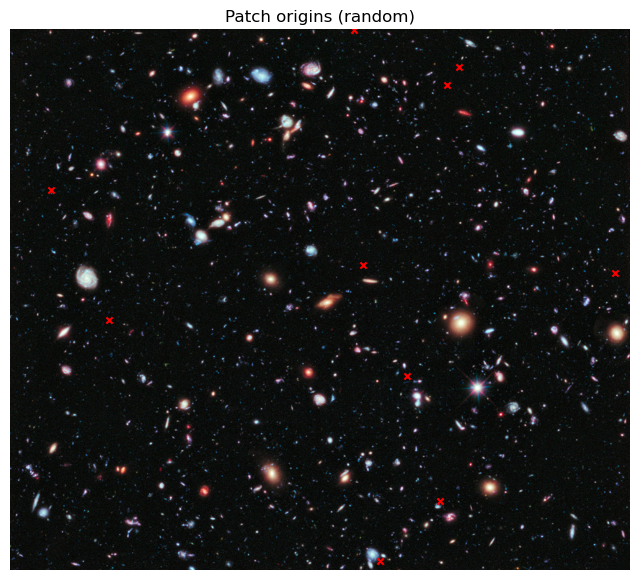

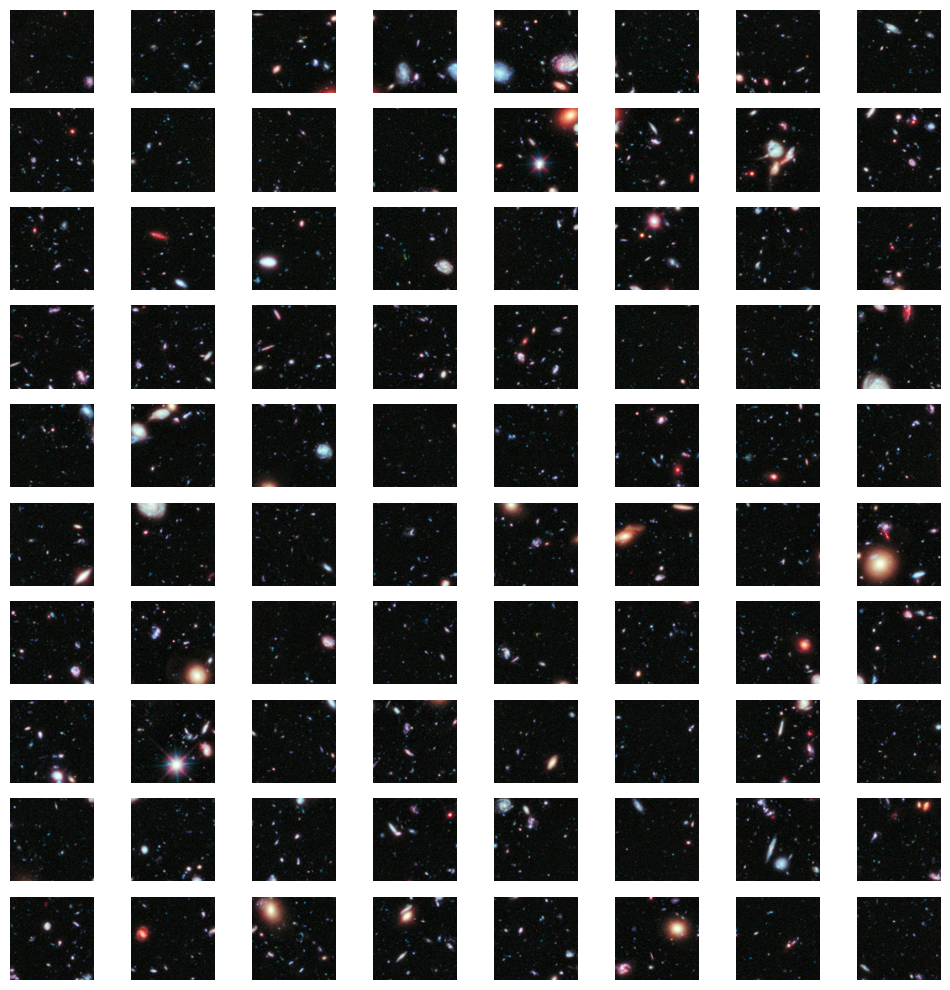

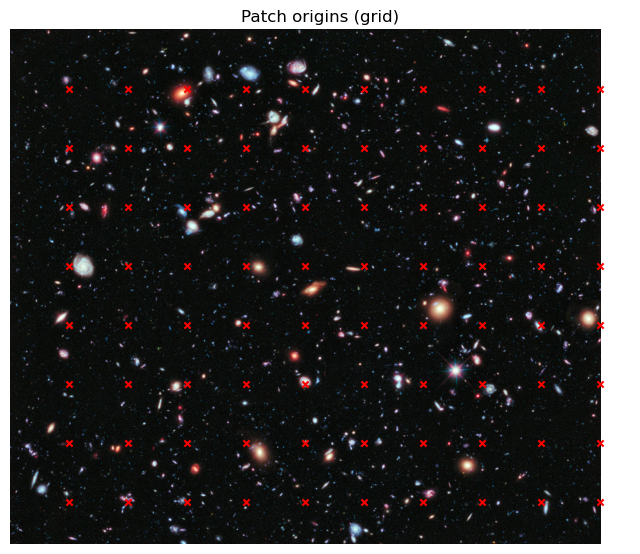

In [24]:
# Test on sklearn images
image = data.hubble_deep_field()
print(image.shape)
plt.imshow(image)

patches, coordinates = CreatePatches(image, 100, 10, 0, method = 'random', mirror_edges=True)

n = len(patches)
cols = int(math.sqrt(n))
rows = math.ceil(n/cols)
plt.figure(figsize = (10,10))
for i, patch in enumerate(patches):
    plt.subplot(rows, cols, i+1)
    plt.imshow(patch)
    plt.axis('off')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.scatter(coordinates[:, 1], coordinates[:, 0], c='red', s=20, marker='x')
plt.title('Patch origins (random)')
plt.axis('off')
plt.show()

image = data.hubble_deep_field()

patches, coordinates = CreatePatches(image, 100, 10, 0, method = 'grid', mirror_edges=True)

n = len(patches)
cols = int(math.sqrt(n))
rows = math.ceil(n/cols)
plt.figure(figsize = (10,10))
for i, patch in enumerate(patches):
    plt.subplot(rows, cols, i+1)
    plt.imshow(patch)
    plt.axis('off')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.scatter(coordinates[:, 1], coordinates[:, 0], c='red', s=20, marker='x')
plt.title('Patch origins (grid)')
plt.axis('off')
plt.show()